# Take-Home Bonus — Hyperparameter Tuning & Scaling
**Type:** [Take-Home Extension]  
**No runtime ceiling.** Run this offline, not during the workshop session.

This notebook covers three topics that were deliberately out of scope during the live session:

1. **HPO for LightGBM** — Optuna-based search over the lag feature pipeline
2. **HPO for NHITS** — Neural architecture and training search
3. **Scaling beyond 1,000 series** — What changes when you go to 100,000 SKUs

---

**Prerequisites:**
- Complete the workshop session through Module 8
- All artifacts in `artifacts/` must exist (run `from src.checkpointing import list_checkpoints; list_checkpoints()` to verify)
- Install Optuna: `pip install optuna`
- Set `TUNE_MODELS = True` in `config.py` or override it in the cell below

**Expected runtime:** 30–90 minutes depending on `N_TRIALS` and hardware.

---
## B.1 — Setup
**[Take-Home Extension]**

In [4]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import warnings
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

matplotlib.rcParams['figure.figsize'] = (12, 4)
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    print(f"Optuna {optuna.__version__} available.")
except ImportError:
    raise ImportError(
        "Optuna not found. Install with: pip install optuna\n"
        "Optuna is not in requirements.txt — it is a take-home only dependency."
    )

import lightgbm as lgb
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS

from config import (
    ARTIFACT_DIR,
    PARAMS_DIR,
    HORIZON,
    SEASON_LENGTH,
    N_WINDOWS,
    STEP_SIZE,
    REFIT,
    MICRO_SUBSET_N,
    WORKSHOP_SUBSET_N,
    RANDOM_SEED,
)
from src.checkpointing import load_checkpoint
from src.evaluation import score_forecasts, pooled_wmape
from src.schemas import validate_forecast

# Override config toggle — set True to actually run search
# Set False to read the structure without triggering long runs
TUNE_MODELS = True   # Change to False if you just want to read the code
N_TRIALS    = 100     # Number of Optuna trials per model — increase for better results
FULL_DATESET = True      # Set to False to use smaller subsets for quick testing

print(f"TUNE_MODELS = {TUNE_MODELS}")
print(f"N_TRIALS    = {N_TRIALS}")
print(f"RANDOM_SEED = {RANDOM_SEED}")

Optuna 4.7.0 available.
TUNE_MODELS = True
N_TRIALS    = 100
RANDOM_SEED = 42


---
## B.2 — Load Data
**[Take-Home Extension]**

In [5]:
panel = load_checkpoint("03_validated_panel")

# Use micro subset for HPO — tuning on 50 series is fast and representative
top_series = (
    panel.groupby("unique_id")["y"]
    .sum()
    .sort_values(ascending=False)
    .head(MICRO_SUBSET_N)
    .index
)
if FULL_DATESET:
    micro = panel.copy()
else:
    micro = panel[panel["unique_id"].isin(top_series)].copy()

print(f"HPO panel: {micro['unique_id'].nunique()} series, {len(micro):,} rows")
print(f"Tuning on micro subset keeps each trial under ~30 seconds.")


  ✓ RED PATH RECOVERY COMPLETE
    Artifact : 03_validated_panel
    File     : 03_validated_panel.parquet
    Rows     : 1,941,000

HPO panel: 1000 series, 1,941,000 rows
Tuning on micro subset keeps each trial under ~30 seconds.


---
## B.3 — HPO for LightGBM via Optuna
**[Take-Home Extension]**

Two separate tuning runs, each saved to its own JSON file:

**B.3a — Default Objective**
Searches the standard LightGBM regression hyperparameters (regression_l2). Good baseline for any time series.

**B.3b — Tweedie Objective**
Fixes `objective='tweedie'` and additionally tunes `tweedie_variance_power`. Tweedie regression is suited to retail demand data with heavy right tails and intermittent zeros — it models the compound Poisson–Gamma process directly rather than penalising all residuals uniformly.

The two runs are **completely separate** — the objective is fixed per run so its impact can be isolated in the B.4 comparison.

Parameters searched in both runs:
- `num_leaves` — model complexity
- `learning_rate` — step size
- `n_estimators` — number of boosting rounds
- `min_child_samples` — regularization via minimum leaf size
- `subsample` and `colsample_bytree` — stochastic regularization
- `reg_alpha`, `reg_lambda` — L1/L2 regularization

Tweedie run additionally searches:
- `tweedie_variance_power` — variance-mean relationship (1.0 ≈ Poisson, 2.0 ≈ Gamma; 1.2–1.6 typically works best for retail demand)

In [6]:
# B.3a — LightGBM HPO via AutoMLForecast (Default Objective)
# AutoMLForecast wraps Optuna internally — no manual objective function needed.
# Saves best params to mlforecast_lgb_tuned.json (backward compat) and
# mlforecast_lgb_tuned_default_obj.json (explicit name for B.4 comparison).

from mlforecast.auto import AutoMLForecast, AutoLightGBM
from mlforecast.lag_transforms import RollingMean
import optuna

def lgb_init_config(trial: optuna.Trial) -> dict:
    """Search space for MLForecast constructor kwargs (shared by both runs)."""
    lags_choice = trial.suggest_categorical("lags", ["7_14_28", "7_14_21_28", "7_28"])
    lags = [int(x) for x in lags_choice.split('_')]
    return {
        "lags": lags,
        "lag_transforms": {lags[0]: [RollingMean(window_size=28)]},
        "date_features": ["dayofweek", "month"],
    }

def lgb_fit_config(trial: optuna.Trial) -> dict:
    """Search space for LGBMRegressor kwargs — default objective."""
    return {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 15, 127),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),
        "random_state":      RANDOM_SEED,
        "n_jobs":            -1,
        "verbosity":         -1,
    }

if TUNE_MODELS:
    print(f"Running LightGBM HPO (default objective): {N_TRIALS} trials...")
    auto_mlf_default = AutoMLForecast(
        models=[AutoLightGBM(config=lgb_fit_config)],
        freq="D",
        init_config=lgb_init_config,
    )
    auto_mlf_default.fit(
        micro,
        n_windows=N_WINDOWS,
        h=HORIZON,
        num_samples=N_TRIALS,
        step_size=STEP_SIZE,
        refit=REFIT,
        study_kwargs={"sampler": optuna.samplers.TPESampler(seed=RANDOM_SEED)},
    )

    best_default = dict(auto_mlf_default.results_["AutoLightGBM"].best_params)
    best_lags_str = best_default.pop('lags', '7_14_28')
    best_lags_default = [int(x) for x in best_lags_str.split('_')]
    best_default.update({'random_state': RANDOM_SEED, 'n_jobs': -1, 'verbosity': -1})

    tuned_params = {'_comment': 'AutoMLForecast Optuna-tuned params (default objective).', **best_default}
    for fname in ['mlforecast_lgb_tuned.json', 'mlforecast_lgb_tuned_default_obj.json']:
        with open(PARAMS_DIR / fname, 'w') as fh:
            json.dump(tuned_params, fh, indent=2)

    print(f"\nBest LightGBM (default objective):")
    print(f"  wMAPE  : {auto_mlf_default.results_['AutoLightGBM'].best_value:.4f}")
    print(f"  Params : {auto_mlf_default.results_['AutoLightGBM'].best_params}")
    print(f"  Saved  : mlforecast_lgb_tuned.json, mlforecast_lgb_tuned_default_obj.json")
else:
    print("TUNE_MODELS = False — skipping LightGBM default-objective HPO.")
    best_default, best_lags_default = {}, [7, 14, 28]

Running LightGBM HPO (default objective): 100 trials...

Best LightGBM (default objective):
  wMAPE  : 0.3312
  Params : {'n_estimators': 675, 'learning_rate': 0.026585908882109703, 'num_leaves': 95, 'min_child_samples': 35, 'subsample': 0.8323930520817325, 'colsample_bytree': 0.9088540087875863, 'reg_alpha': 0.006250391643347274, 'reg_lambda': 0.011262001072312433, 'lags': '7_14_21_28'}
  Saved  : mlforecast_lgb_tuned.json, mlforecast_lgb_tuned_default_obj.json


In [7]:
# B.3b — LightGBM HPO with Tweedie Objective
# Fixes objective='tweedie' and also tunes tweedie_variance_power.
# Uses the same lgb_init_config lag search space as B.3a.
# Saves to mlforecast_lgb_tuned_tweedie.json — separate file, separate study.

def lgb_fit_config_tweedie(trial: optuna.Trial) -> dict:
    """Search space for LGBMRegressor kwargs — tweedie objective fixed."""
    return {
        "objective":              "tweedie",
        "tweedie_variance_power": trial.suggest_float("tweedie_variance_power", 1.0, 1.9),
        "n_estimators":           trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate":          trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "num_leaves":             trial.suggest_int("num_leaves", 15, 127),
        "min_child_samples":      trial.suggest_int("min_child_samples", 5, 100),
        "subsample":              trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":       trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":              trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        "reg_lambda":             trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),
        "random_state":           RANDOM_SEED,
        "n_jobs":                 -1,
        "verbosity":              -1,
    }

if TUNE_MODELS:
    print(f"Running LightGBM HPO (tweedie objective): {N_TRIALS} trials...")
    auto_mlf_tweedie = AutoMLForecast(
        models=[AutoLightGBM(config=lgb_fit_config_tweedie)],
        freq="D",
        init_config=lgb_init_config,  # same lag search space as B.3a
    )
    auto_mlf_tweedie.fit(
        micro,
        n_windows=N_WINDOWS,
        h=HORIZON,
        num_samples=N_TRIALS,
        step_size=STEP_SIZE,
        refit=REFIT,
        study_kwargs={"sampler": optuna.samplers.TPESampler(seed=RANDOM_SEED)},
    )

    best_tweedie = dict(auto_mlf_tweedie.results_["AutoLightGBM"].best_params)
    best_lags_str_tw = best_tweedie.pop('lags', '7_14_28')
    best_lags_tweedie = [int(x) for x in best_lags_str_tw.split('_')]
    best_tweedie.update({'random_state': RANDOM_SEED, 'n_jobs': -1, 'verbosity': -1})

    tweedie_path = PARAMS_DIR / 'mlforecast_lgb_tuned_tweedie.json'
    with open(tweedie_path, 'w') as fh:
        json.dump({'_comment': 'AutoMLForecast Optuna-tuned params (tweedie objective).', **best_tweedie}, fh, indent=2)

    print(f"\nBest LightGBM (tweedie objective):")
    print(f"  wMAPE  : {auto_mlf_tweedie.results_['AutoLightGBM'].best_value:.4f}")
    print(f"  Params : {auto_mlf_tweedie.results_['AutoLightGBM'].best_params}")
    print(f"  Saved  : {tweedie_path.name}")
else:
    print("TUNE_MODELS = False — skipping LightGBM tweedie-objective HPO.")
    best_tweedie, best_lags_tweedie = {}, [7, 14, 28]

Running LightGBM HPO (tweedie objective): 100 trials...

Best LightGBM (tweedie objective):
  wMAPE  : 0.3314
  Params : {'tweedie_variance_power': 1.3957778739907227, 'n_estimators': 768, 'learning_rate': 0.01097922166612825, 'num_leaves': 17, 'min_child_samples': 97, 'subsample': 0.6008868517264999, 'colsample_bytree': 0.6366934640049406, 'reg_alpha': 0.013630654982979768, 'reg_lambda': 0.00036301513426285084, 'lags': '7_14_21_28'}
  Saved  : mlforecast_lgb_tuned_tweedie.json


---
## B.4 — 3-Way LightGBM Comparison
**[Take-Home Extension]**

Compares the workshop default config against both tuned variants using the same cross-validation protocol (`N_WINDOWS` windows, pooled wMAPE):

1. **Default** — workshop params from `mlforecast_lgb_default.json`
2. **Tuned (default obj)** — Optuna-tuned with regression_l2, from B.3a
3. **Tuned (tweedie)** — Optuna-tuned with tweedie objective, from B.3b

Requires B.3a and B.3b to have been run in the current session (uses in-memory `best_default` / `best_tweedie` dicts).

In [8]:
if TUNE_MODELS:
    import lightgbm as lgb
    from mlforecast import MLForecast
    from mlforecast.lag_transforms import RollingMean as RM

    # --- Workshop default config ---
    default_path = PARAMS_DIR / 'mlforecast_lgb_default.json'
    with open(default_path) as fh:
        default_params = {k: v for k, v in json.load(fh).items() if not k.startswith('_')}
    mlf_wkshp = MLForecast(
        models=[lgb.LGBMRegressor(**default_params)],
        freq='D', lags=[7, 14, 28],
        lag_transforms={7: [RM(window_size=28)]},
        date_features=['dayofweek', 'month'],
    )
    cv_wkshp = mlf_wkshp.cross_validation(
        df=micro, h=HORIZON, n_windows=N_WINDOWS, step_size=STEP_SIZE, refit=REFIT,
    ).reset_index()
    wmape_default = pooled_wmape(cv_wkshp['y'].values, cv_wkshp['LGBMRegressor'].clip(lower=0).values)

    # --- Tuned default objective ---
    mlf_tuned_def = MLForecast(
        models=[lgb.LGBMRegressor(**best_default)],
        freq='D', lags=best_lags_default,
        lag_transforms={best_lags_default[0]: [RM(window_size=28)]},
        date_features=['dayofweek', 'month'],
    )
    cv_tuned_def = mlf_tuned_def.cross_validation(
        df=micro, h=HORIZON, n_windows=N_WINDOWS, step_size=STEP_SIZE, refit=REFIT,
    ).reset_index()
    wmape_tuned_def = pooled_wmape(cv_tuned_def['y'].values, cv_tuned_def['LGBMRegressor'].clip(lower=0).values)

    # --- Tuned tweedie ---
    mlf_tuned_tw = MLForecast(
        models=[lgb.LGBMRegressor(**best_tweedie)],
        freq='D', lags=best_lags_tweedie,
        lag_transforms={best_lags_tweedie[0]: [RM(window_size=28)]},
        date_features=['dayofweek', 'month'],
    )
    cv_tuned_tw = mlf_tuned_tw.cross_validation(
        df=micro, h=HORIZON, n_windows=N_WINDOWS, step_size=STEP_SIZE, refit=REFIT,
    ).reset_index()
    wmape_tuned_tw = pooled_wmape(cv_tuned_tw['y'].values, cv_tuned_tw['LGBMRegressor'].clip(lower=0).values)

    print(f"\nLightGBM 3-Way Comparison ({micro['unique_id'].nunique()} series):")
    print(f"  {'Model':<28} {'wMAPE':>8}  {'vs Default':>10}")
    print(f"  {'-'*50}")
    print(f"  {'Default (workshop)':<28} {wmape_default:>8.4f}  {'—':>10}")
    print(f"  {'Tuned (default obj)':<28} {wmape_tuned_def:>8.4f}  {(wmape_default-wmape_tuned_def)/wmape_default*100:>+9.1f}%")
    print(f"  {'Tuned (tweedie)':<28} {wmape_tuned_tw:>8.4f}  {(wmape_default-wmape_tuned_tw)/wmape_default*100:>+9.1f}%")
    print()
    print('Run build_offline_artifacts.py --stages ml to regenerate artifacts.')
else:
    print('Skipped — set TUNE_MODELS = True to run comparison.')


LightGBM 3-Way Comparison (1000 series):
  Model                           wMAPE  vs Default
  --------------------------------------------------
  Default (workshop)             0.4678           —
  Tuned (default obj)            0.4652       +0.5%
  Tuned (tweedie)                0.4686       -0.2%

Run build_offline_artifacts.py --stages ml to regenerate artifacts.


---
## B.5 — Optuna Trial History Plot
**[Take-Home Extension]**

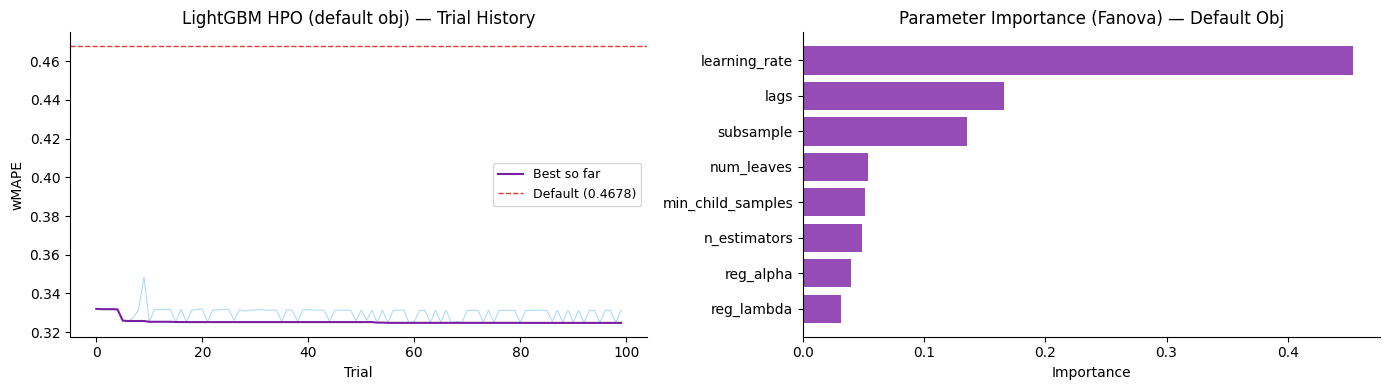

In [9]:
if TUNE_MODELS:
    import optuna

    trials_df = auto_mlf_default.results_["AutoLightGBM"].trials_dataframe()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(trials_df['number'], trials_df['value'],
                 color='#90CAF9', linewidth=0.8, alpha=0.7)
    best_so_far = trials_df['value'].cummin()
    axes[0].plot(trials_df['number'], best_so_far,
                 color='#7B1FA2', linewidth=1.5, label='Best so far')
    axes[0].axhline(wmape_default, color='#E53935', linestyle='--',
                    linewidth=1, label=f'Default ({wmape_default:.4f})')
    axes[0].set_xlabel('Trial')
    axes[0].set_ylabel('wMAPE')
    axes[0].set_title('LightGBM HPO (default obj) — Trial History')
    axes[0].legend(fontsize=9)

    try:
        importances = optuna.importance.get_param_importances(auto_mlf_default.results_["AutoLightGBM"])
        imp_names  = list(importances.keys())[:8]
        imp_values = [importances[k] for k in imp_names]
        axes[1].barh(imp_names, imp_values, color='#7B1FA2', alpha=0.8)
        axes[1].set_title('Parameter Importance (Fanova) — Default Obj')
        axes[1].set_xlabel('Importance')
        axes[1].invert_yaxis()
    except Exception:
        axes[1].text(0.5, 0.5, 'Importance requires >= 4 complete trials',
                     ha='center', va='center', transform=axes[1].transAxes)

    plt.tight_layout()
    plt.show()
else:
    print('Skipped — set TUNE_MODELS = True to see trial history.')

---
## B.6 — HPO for NHITS via Optuna
**[Take-Home Extension]**

NHITS is more sensitive to hyperparameters than LightGBM. The three most impactful levers are:
- `max_steps` — training budget (primary accuracy lever)
- `input_size` — context window relative to horizon
- `learning_rate` — gradient step size

Each NHITS trial is slow relative to LightGBM. Keep `N_TRIALS` at 15–20 for a first pass, and run on GPU if available.

**B.6b** (next cell) compares the tuned config against a default NHITS. `n_windows=1` is used rather than the full `N_WINDOWS` protocol to keep runtime manageable — each `cross_validation` call trains NHITS from scratch.

In [10]:
# B.6 — NHITS HPO via AutoNHITS (Nixtla-native)
# AutoNHITS wraps Optuna internally. We use the optuna backend for consistency.
# Tunes on micro subset only — each CPU trial is 30-90s.

from neuralforecast import NeuralForecast
from neuralforecast.auto import AutoNHITS
from neuralforecast.losses.pytorch import MAE
import optuna

def nhits_config(trial: optuna.Trial) -> dict:
    """Custom NHITS search space."""
    nfd_str = trial.suggest_categorical("n_freq_downsample", ["2_1_1", "4_2_1", "1_1_1"])
    # MockTrial (used during AutoNHITS.__init__ validation) returns the full list of choices
    # rather than a single value, so we guard against that here.
    if isinstance(nfd_str, list):
        nfd_str = nfd_str[0]
    return {
        "input_size":              trial.suggest_categorical("input_size", [28, 56, 84]),
        "max_steps":              trial.suggest_int("max_steps", 100, 500, step=100),
        "learning_rate":          trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
        "batch_size":             trial.suggest_categorical("batch_size", [16, 32, 64]),
        "n_freq_downsample":      [int(x) for x in nfd_str.split("_")],
        "val_check_steps":        50,
        "early_stop_patience_steps": -1,
        "random_seed":            RANDOM_SEED,
        "enable_progress_bar":    False,
        "enable_model_summary":   False,
    }

if TUNE_MODELS:
    nhits_trials = max(5, N_TRIALS // 3)
    print(f'Running NHITS HPO via AutoNHITS: {nhits_trials} trials on micro subset ({micro["unique_id"].nunique()} series)...')

    auto_nhits = AutoNHITS(
        h=HORIZON,
        loss=MAE(),
        config=nhits_config,
        num_samples=nhits_trials,
        backend="optuna",
        verbose=False,
    )
    nf_auto = NeuralForecast(models=[auto_nhits], freq='D')
    nf_auto.fit(micro, val_size=HORIZON)

    # NeuralForecast deep-copies models at init, so results live on the fitted
    # copy inside nf_auto.models[0], not on the original auto_nhits object.
    fitted_auto = nf_auto.models[0]
    best_nhits = fitted_auto.results.best_trial.user_attrs["ALL_PARAMS"]
    print(f'\nBest NHITS trial:')
    print(f'  Loss   : {fitted_auto.results.best_value:.4f}')
    print(f'  Params : {best_nhits}')

    # Overwrite nhits_tuned.json with Optuna results
    nfd = best_nhits.get('n_freq_downsample', '2_1_1')
    nhits_tuned_output = {
        '_comment':                 'AutoNHITS Optuna-tuned params.',
        'h':                        HORIZON,
        'input_size':              best_nhits.get('input_size', 56),
        'max_steps':               best_nhits.get('max_steps', 300),
        'learning_rate':           best_nhits.get('learning_rate', 0.001),
        'batch_size':              best_nhits.get('batch_size', 32),
        'n_freq_downsample':       [int(x) for x in nfd.split('_')] if isinstance(nfd, str) else nfd,
        'val_check_steps':         50,
        'early_stop_patience_steps': -1,
        'random_seed':             RANDOM_SEED,
        'enable_progress_bar':     False,
        'enable_model_summary':    False,
    }
    nhits_path = PARAMS_DIR / 'nhits_tuned.json'
    with open(nhits_path, 'w') as f:
        json.dump(nhits_tuned_output, f, indent=2)
    print(f'Saved tuned params to: {nhits_path.name}')
    print('Run build_offline_artifacts.py --stages dl to regenerate artifacts.')
else:
    print('Skipped — set TUNE_MODELS = True to run NHITS HPO.')

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Running NHITS HPO via AutoNHITS: 33 trials on micro subset (1000 series)...


`Trainer.fit` stopped: `max_steps=300` reached.
Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer.fit` stopped: `max_steps=100` reached.
Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer.fit` stopped: `max_steps=500` reached.
Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to 


Best NHITS trial:
  Loss   : 4.5741
  Params : {'input_size': 84, 'max_steps': 500, 'learning_rate': 0.0006753586119744053, 'batch_size': 32, 'n_freq_downsample': [2, 1, 1], 'val_check_steps': 50, 'early_stop_patience_steps': -1, 'random_seed': 42, 'enable_progress_bar': False, 'enable_model_summary': False, 'h': 28, 'loss': MAE(), 'valid_loss': MAE()}
Saved tuned params to: nhits_tuned.json
Run build_offline_artifacts.py --stages dl to regenerate artifacts.


In [11]:
# B.6b — Compare Tuned vs Default NHITS
# Uses n_windows=1 (single held-out window) to keep runtime manageable.
# best_nhits comes from B.6 above (ALL_PARAMS from Optuna best trial).

if TUNE_MODELS:
    from neuralforecast.models import NHITS

    print(f"Scoring default vs tuned NHITS on {micro['unique_id'].nunique()} series (n_windows=1)...")

    # Default NHITS — representative config with typical values
    nhits_default_model = NHITS(
        h=HORIZON,
        input_size=2 * HORIZON,
        max_steps=300,
        loss=MAE(),
        batch_size=32,
        learning_rate=1e-3,
        early_stop_patience_steps=-1,
        random_seed=RANDOM_SEED,
        enable_progress_bar=False,
        enable_model_summary=False,
    )
    print("  Fitting default NHITS...")
    cv_nhits_default = NeuralForecast(models=[nhits_default_model], freq='D').cross_validation(
        micro, h=HORIZON, n_windows=1
    ).reset_index()
    wmape_nhits_default = pooled_wmape(
        cv_nhits_default['y'].values,
        cv_nhits_default['NHITS'].clip(lower=0).values,
    )

    # Tuned NHITS — best params dict from AutoNHITS Optuna study (B.6)
    nhits_tuned_model = NHITS(h=HORIZON, loss=MAE(), **best_nhits)
    print("  Fitting tuned NHITS...")
    cv_nhits_tuned = NeuralForecast(models=[nhits_tuned_model], freq='D').cross_validation(
        micro, h=HORIZON, n_windows=1
    ).reset_index()
    wmape_nhits_tuned = pooled_wmape(
        cv_nhits_tuned['y'].values,
        cv_nhits_tuned['NHITS'].clip(lower=0).values,
    )

    improvement = (wmape_nhits_default - wmape_nhits_tuned) / wmape_nhits_default * 100
    print(f"\nNHITS Tuning Results ({micro['unique_id'].nunique()} series, n_windows=1):")
    print(f"  {'Model':<20} {'wMAPE':>8}  {'vs Default':>10}")
    print(f"  {'-'*42}")
    print(f"  {'Default':<20} {wmape_nhits_default:>8.4f}  {'—':>10}")
    print(f"  {'Tuned':<20} {wmape_nhits_tuned:>8.4f}  {improvement:>+9.1f}%")
    print(f"\n  Best config: {best_nhits}")
else:
    print('Skipped — set TUNE_MODELS = True to run NHITS comparison.')

Seed set to 42


Scoring default vs tuned NHITS on 1000 series (n_windows=1)...
  Fitting default NHITS...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer.fit` stopped: `max_steps=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


TypeError: neuralforecast.models.nhits.NHITS() got multiple values for keyword argument 'h'

---
## B.7 — HPO Takeaways: What Actually Matters
**[Take-Home Extension]**

After running HPO on both models, the pattern is almost always the same:

**For LightGBM:**  
The parameter importance plot usually shows `learning_rate` and `num_leaves` as the dominant factors. `subsample` and `colsample_bytree` matter when the dataset is large and prone to overfitting. On 50–1,000 dense retail series, the default params are often within 1–2 wMAPE points of the best tuned config. **The lag structure (which lags to include) frequently matters more than any individual LightGBM hyperparameter.**

**For NHITS:**  
`max_steps` and `input_size` dominate. `learning_rate` matters on longer runs. The `n_freq_downsample` configuration affects what temporal scales the model attends to — `[4, 2, 1]` is better for data with both weekly and monthly patterns.

**The honest HPO cost calculation:**  
30 Optuna trials for LightGBM on 50 series takes roughly 15 minutes. On 1,000 series it takes hours. On 100,000 series it is not practical without distributed compute. At that scale, tuning is done on a representative sample and validated on a stratified holdout — never on the full portfolio.

---
## B.8 — Scaling Beyond the Workshop: What Changes at 100,000 SKUs
**[Take-Home Extension]**

This section is conceptual — no code to run. It maps the workshop pipeline to the production challenges that appear when you scale from 1,000 to 100,000+ series.

### B.8.1 — Data Layer

**Workshop approach:** Load a 25MB parquet from disk. Fits in RAM on any laptop.

**At 100,000 SKUs × 3 years daily:** ~75M rows, ~3GB parquet. Does not fit in a Colab notebook. Requires partitioned storage (Parquet on S3, Delta Lake, or Hive) and lazy loading.

**What to build:**
- Partitioned parquet by `store_id` or `category` — models train on one partition at a time
- Schema validation at ingestion, not just at training time
- Incremental append pattern — new data is appended to the partition, not reloaded from scratch

---

### B.8.2 — Feature Pipeline

**Workshop approach:** MLForecast computes lags on the fly during cross-validation.

**At scale:** On-the-fly lag computation is too slow and not auditable. You need:
- A feature store (Feast, Tecton, or a custom solution) that precomputes lags and rolling statistics once per day
- Versioned feature snapshots so you can reproduce any historical training run
- A backfill job that recomputes features when upstream data is corrected

**The most common failure mode:** Late data invalidates precomputed lags silently. Your model trains on lag_7 values computed from data that arrives by 6am. The 3% of SKUs with data arriving at 10am get stale lags. You will not see this in your wMAPE — you will see it in stockout rates on those SKUs.

---

### B.8.3 — Training

**Workshop approach:** Single LightGBM global model trains on all series in one call.

**At scale:** A single global model works surprisingly well up to a few hundred thousand series. Beyond that:
- Hierarchical modeling by category — one LightGBM per product category, shared feature schema
- Distributed training via Spark or Dask for embarrassingly parallel models (AutoETS per series)
- Neural models (NHITS) trained on GPU clusters with data parallelism

**NHITS-specific:** At 100,000 series × 3 years × daily, a single NeuralForecast training run takes 4–8 hours on a single GPU. Practical options: train on a stratified 10,000-series sample and validate transfer, or use spot GPU instances on a weekly retraining schedule.

---

### B.8.4 — Evaluation

**Workshop approach:** Score all models in a single `score_forecasts()` call. Results fit in a 6-row leaderboard.

**At scale:** You need segment-level evaluation:
- By product category
- By sales velocity tier (A/B/C classification)
- By store region
- By seasonal pattern type

A global wMAPE of 0.22 can hide a 0.45 wMAPE on your most volatile SKUs — exactly the ones that drive your safety stock costs. Pooled metrics are the right top-line measure, but segment breakdowns are what drive model improvement decisions.

---

### B.8.5 — Serving

**Workshop approach:** Run the notebook. Forecasts saved to a local CSV.

**At scale:** A forecast serving system has three components:
1. **Batch inference job** — runs on a schedule, writes forecasts to a database or object store
2. **Freshness monitor** — alerts if forecasts are not updated by the SLA deadline
3. **Fallback policy** — serves the last valid forecast if the current batch fails, logs the fallback event

The fallback policy is the most important and least-built component. Define it before you deploy.

---

### B.8.6 — Monitoring

**Workshop approach:** None — the workshop is a single evaluation run.

**At scale:** You need at least three monitoring layers:
1. **Input monitoring** — flag series where recent actuals have shifted dramatically from historical patterns (demand shock, assortment change, data quality issue)
2. **Prediction monitoring** — flag forecasts that are implausibly large or zero for non-zero SKUs
3. **Accuracy monitoring** — rolling wMAPE tracked week-over-week, with automated retraining trigger when it degrades beyond a threshold

The hardest monitoring problem in forecasting is distinguishing between model degradation (retrain) and demand structure change (retrain with new features). Both look identical in the accuracy metric.

---
## B.9 — Recommended Next Steps
**[Take-Home Extension]**

If you want to go deeper on any topic covered in this workshop:

**On evaluation rigor:**
- Hyndman & Koehler (2006) — "Another look at measures of forecast accuracy" — the academic foundation for why MAE/MAPE/wMAPE behave the way they do
- Gneiting & Raftery (2007) — "Strictly Proper Scoring Rules" — the theoretical basis for Interval Score

**On the Nixtla stack:**
- StatsForecast, MLForecast, NeuralForecast documentation at `nixtlaverse.nixtla.io`
- The M5 competition paper (Makridakis et al., 2022) — context for why this dataset was chosen

**On Chronos:**
- Ansari et al. (2024) — "Chronos: Learning the Language of Time Series" — the original paper
- The AutoGluon-TimeSeries documentation covers the full Chronos family including larger variants

**On production systems:**
- *Designing Machine Learning Systems* (Huyen, 2022) — Chapters 7–9 cover feature stores, model deployment, and monitoring patterns that apply directly to forecasting
- Feast documentation (`feast.dev`) — open source feature store used in production at scale

**On the book:**
- *Modern Time Series Forecasting with Python* by Jeff Tackes and Manu Joseph (Packt Publishing) covers all six models from today in full detail, including the production patterns this workshop only outlined.

---

*Good luck with the build.*  
*— Jeff & Manu*